# Greenfilling trade-offs

A first, exploratory look at the small campaign. The goal is to get a feel for what greenfilling (optimizing either carbon or water) does to the environmental footprint and to job performance, compared to plain EASY backfilling on the same workload and the same environmental window.

The campaign now covers two Mustang workloads: `stress` and `slack`. The stress workload keeps the machine busy, so there is not much room in the schedule to play with, and I would expect any environmental effect to be small there. The slack workload submits more jobs over the same week but with more scheduling slack, so in principle the backfiller has more freedom to react to the signal. The analysis below keeps the two workloads separate so the comparison stays paired and fair.

This analysis looks at replay jobs separately before saying anything about performance.

## Load Campaign Metadata

In [40]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tomllib


pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


root = Path.cwd()
if not (root / "experiments").exists():
    root = root.parent

campaign_path = root / "experiments" / "experiments_small.toml"
windows_path = root / "intensities" / "traces" / "small" / "windows.csv"
out_dir = root / "experiments" / "out"

print(f"root: {root}")
print(f"campaign: {campaign_path}")
print(f"windows: {windows_path}")
print(f"outputs: {out_dir}")

root: /Users/lucas/ws/doct/experimental-artifacts
campaign: /Users/lucas/ws/doct/experimental-artifacts/experiments/experiments_small.toml
windows: /Users/lucas/ws/doct/experimental-artifacts/intensities/traces/small/windows.csv
outputs: /Users/lucas/ws/doct/experimental-artifacts/experiments/out


In [41]:
def parse_experiment_name(name):
    baseline = re.fullmatch(r"easy_bf_([^_]+)_([A-Z]{2})_(\d{4}-\d{2}-\d{2})", name)
    if baseline:
        workload, zone, start_date = baseline.groups()
        return {
            "variant": "easy_bf",
            "objective": "baseline",
            "workload_label": workload,
            "zone": zone,
            "start_date": start_date,
        }

    greenfilling = re.fullmatch(
        r"greenfilling_(carbon|water)_([^_]+)_([A-Z]{2})_(\d{4}-\d{2}-\d{2})",
        name,
    )
    if greenfilling:
        objective, workload, zone, start_date = greenfilling.groups()
        return {
            "variant": f"greenfilling_{objective}",
            "objective": objective,
            "workload_label": workload,
            "zone": zone,
            "start_date": start_date,
        }

    raise ValueError(f"Unexpected experiment name: {name}")


with campaign_path.open("rb") as file:
    campaign = pd.DataFrame(tomllib.load(file)["experiment"])

name_parts = pd.DataFrame([parse_experiment_name(name) for name in campaign["name"]])
campaign = pd.concat([campaign, name_parts], axis=1)

windows = pd.read_csv(windows_path)

display(campaign.head())
display(windows.head())

,name,workload,platform,environmental_trace,variant_name,variant_options,variant,objective,workload_label,zone,start_date
0,easy_bf_stress_DE_2019-02-04,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2019-02-04.csv,easy_bf,,easy_bf,baseline,stress,DE,2019-02-04
1,easy_bf_stress_DE_2019-04-22,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2019-04-22.csv,easy_bf,,easy_bf,baseline,stress,DE,2019-04-22
2,easy_bf_stress_DE_2022-06-27,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2022-06-27.csv,easy_bf,,easy_bf,baseline,stress,DE,2022-06-27
3,easy_bf_stress_DE_2023-05-15,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2023-05-15.csv,easy_bf,,easy_bf,baseline,stress,DE,2023-05-15
4,easy_bf_stress_DE_2024-01-01,../workloads and platforms/small/mustang_stres...,../workloads and platforms/mustang.xml,../intensities/traces/small/DE_2024-01-01.csv,easy_bf,,easy_bf,baseline,stress,DE,2024-01-01


,zone,file,start_date,season,year,mean_carbon,mean_water,swing_carbon,swing_water
0,DE,traces/small/DE_2019-02-04.csv,2019-02-04,winter,2019,287.1696,1.2927,0.3065,0.2646
1,DE,traces/small/DE_2019-04-22.csv,2019-04-22,spring,2019,266.2537,1.5290,0.4340,0.4289
2,DE,traces/small/DE_2022-06-27.csv,2022-06-27,summer,2022,387.8807,1.6624,0.5225,0.5640
3,DE,traces/small/DE_2023-05-15.csv,2023-05-15,spring,2023,254.2366,1.4861,0.7373,0.7356
4,DE,traces/small/DE_2024-01-01.csv,2024-01-01,winter,2024,255.2737,1.2785,0.4000,0.4007


## Check Result Completeness

In [42]:
result_files = []
for row in campaign.itertuples(index=False):
    experiment_dir = out_dir / row.name
    result_files.append(
        {
            "name": row.name,
            "variant": row.variant,
            "workload_label": row.workload_label,
            "zone": row.zone,
            "start_date": row.start_date,
            "has_directory": experiment_dir.exists(),
            "has_schedule": (experiment_dir / "out_schedule.csv").exists(),
            "has_jobs": (experiment_dir / "out_jobs.csv").exists(),
            "has_environmental_footprint": (experiment_dir / "out_environmental_footprint.csv").exists(),
        }
    )

result_files = pd.DataFrame(result_files)

display(
    result_files.groupby(["variant", "workload_label"])[[
        "has_directory",
        "has_schedule",
        "has_jobs",
        "has_environmental_footprint",
    ]].sum()
)

missing = result_files[
    ~(result_files["has_schedule"] & result_files["has_jobs"])
]

if missing.empty:
    print(f"All {len(result_files)} experiments have schedule and job outputs.")
else:
    display(missing.sort_values(["variant", "workload_label", "zone", "start_date"]))

has_directory  has_schedule  has_jobs  \
variant             workload_label                                          
easy_bf             slack                      24            24        24   
                    stress                     24            24        24   
greenfilling_carbon slack                      24            24        24   
                    stress                     24            24        24   
greenfilling_water  slack                      24            24        24   
                    stress                     24            24        24   

                                    has_environmental_footprint  
variant             workload_label                               
easy_bf             slack                                    24  
                    stress                                   24  
greenfilling_carbon slack                                    24  
                    stress                                   24  
greenfilling_water  slack                                    24  
                    stress                                   24

All 144 experiments have schedule and job outputs.


## Load Result Tables

This section builds the reusable tables for the rest of the notebook. `schedules` has one row per experiment. `jobs` has one row per simulated job and labels each job as either `context` or `replay`.

For slowdown, the main metric is average bounded slowdown with a 10-second floor: `max(turnaround_time / max(execution_time, 10), 1)`. This keeps very short jobs from dominating the comparison while preserving the direction of the performance trade-off.

In [43]:
metadata_columns = [
    "name",
    "variant",
    "objective",
    "workload_label",
    "zone",
    "start_date",
]

campaign_metadata = campaign[metadata_columns].set_index("name")
complete_results = result_files[result_files["has_schedule"] & result_files["has_jobs"]]

schedule_frames = []
job_frames = []

for experiment_name in complete_results["name"]:
    experiment_dir = out_dir / experiment_name
    metadata = campaign_metadata.loc[experiment_name].to_dict()

    schedule = pd.read_csv(experiment_dir / "out_schedule.csv")
    schedule.insert(0, "name", experiment_name)
    for key, value in metadata.items():
        schedule[key] = value
    schedule_frames.append(schedule)

    experiment_jobs = pd.read_csv(experiment_dir / "out_jobs.csv")
    experiment_jobs.insert(0, "name", experiment_name)
    for key, value in metadata.items():
        experiment_jobs[key] = value
    job_frames.append(experiment_jobs)

schedules = pd.concat(schedule_frames, ignore_index=True)
jobs = pd.concat(job_frames, ignore_index=True)

jobs["job_kind"] = jobs["job_id"].str.startswith("ctx_").map({True: "context", False: "replay"})
jobs["walltime_reached"] = jobs["final_state"].eq("COMPLETED_WALLTIME_REACHED")
jobs["succeeded"] = jobs["success"].eq(1)
bounded_slowdown_floor_seconds = 10.0
jobs["bounded_slowdown"] = np.maximum(
    jobs["turnaround_time"] / jobs["execution_time"].clip(lower=bounded_slowdown_floor_seconds),
    1.0,
)

schedules = schedules.merge(
    windows,
    on=["zone", "start_date"],
    how="left",
    validate="many_to_one",
)

print(f"schedules: {len(schedules)} rows")
print(f"jobs: {len(jobs)} rows")

display(schedules[["name", "variant", "zone", "start_date", "season", "nb_jobs", "success_rate"]].head())
print(f"bounded slowdown floor: {bounded_slowdown_floor_seconds:g} seconds")
display(jobs[["name", "job_id", "job_kind", "final_state", "waiting_time", "stretch", "bounded_slowdown"]].head())

schedules: 144 rows
jobs: 150984 rows


,name,variant,zone,start_date,season,nb_jobs,success_rate
0,easy_bf_stress_DE_2019-02-04,easy_bf,DE,2019-02-04,winter,797,0.835634
1,easy_bf_stress_DE_2019-04-22,easy_bf,DE,2019-04-22,spring,797,0.835634
2,easy_bf_stress_DE_2022-06-27,easy_bf,DE,2022-06-27,summer,797,0.835634
3,easy_bf_stress_DE_2023-05-15,easy_bf,DE,2023-05-15,spring,797,0.835634
4,easy_bf_stress_DE_2024-01-01,easy_bf,DE,2024-01-01,winter,797,0.835634


bounded slowdown floor: 10 seconds


,name,job_id,job_kind,final_state,waiting_time,stretch,bounded_slowdown
0,easy_bf_stress_DE_2019-02-04,ctx_queued10,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
1,easy_bf_stress_DE_2019-02-04,ctx_queued1,context,COMPLETED_SUCCESSFULLY,0.0,1.000000,1.000000
2,easy_bf_stress_DE_2019-02-04,ctx_queued12,context,COMPLETED_SUCCESSFULLY,36.0,1.631579,1.631579
3,easy_bf_stress_DE_2019-02-04,ctx_queued2,context,COMPLETED_SUCCESSFULLY,93.0,1.259777,1.259777
4,easy_bf_stress_DE_2019-02-04,ctx_queued3,context,COMPLETED_SUCCESSFULLY,93.0,1.051638,1.051638


In [44]:
job_metrics = (
    jobs.groupby(["name", "variant", "workload_label", "zone", "start_date", "job_kind"], observed=True)
    .agg(
        jobs=("job_id", "size"),
        succeeded=("succeeded", "sum"),
        walltime_reached=("walltime_reached", "sum"),
        success_rate=("succeeded", "mean"),
        median_waiting_time=("waiting_time", "median"),
        p95_waiting_time=("waiting_time", lambda values: values.quantile(0.95)),
        mean_bounded_slowdown=("bounded_slowdown", "mean"),
    )
    .reset_index()
)

display(
    job_metrics.groupby(["workload_label", "variant", "job_kind"], observed=True)
    .agg(
        runs=("name", "nunique"),
        jobs_per_run=("jobs", "median"),
        median_success_rate=("success_rate", "median"),
        min_success_rate=("success_rate", "min"),
        max_success_rate=("success_rate", "max"),
        median_walltime_reached=("walltime_reached", "median"),
        median_bounded_slowdown=("mean_bounded_slowdown", "median"),
    )
    .round(3)
)

display(job_metrics.head())

runs  jobs_per_run  \
workload_label variant             job_kind                       
slack          easy_bf             context     24         209.0   
                                   replay      24        1091.0   
               greenfilling_carbon context     24         209.0   
                                   replay      24        1091.0   
               greenfilling_water  context     24         209.0   
                                   replay      24        1091.0   
stress         easy_bf             context     24         326.0   
                                   replay      24         471.0   
               greenfilling_carbon context     24         326.0   
                                   replay      24         471.0   
               greenfilling_water  context     24         326.0   
                                   replay      24         471.0   

                                             median_success_rate  \
workload_label variant             job_kind                        
slack          easy_bf             context                 0.923   
                                   replay                  0.896   
               greenfilling_carbon context                 0.923   
                                   replay                  0.871   
               greenfilling_water  context                 0.923   
                                   replay                  0.874   
stress         easy_bf             context                 0.718   
                                   replay                  0.917   
               greenfilling_carbon context                 0.736   
                                   replay                  0.932   
               greenfilling_water  context                 0.730   
                                   replay                  0.931   

                                             min_success_rate  \
workload_label variant             job_kind                     
slack          easy_bf             context              0.923   
                                   replay               0.896   
               greenfilling_carbon context              0.885   
                                   replay               0.844   
               greenfilling_water  context              0.876   
                                   replay               0.845   
stress         easy_bf             context              0.718   
                                   replay               0.917   
               greenfilling_carbon context              0.693   
                                   replay               0.915   
               greenfilling_water  context              0.693   
                                   replay               0.913   

                                             max_success_rate  \
workload_label variant             job_kind                     
slack          easy_bf             context              0.923   
                                   replay               0.896   
               greenfilling_carbon context              0.952   
                                   replay               0.887   
               greenfilling_water  context              0.943   
                                   replay               0.891   
stress         easy_bf             context              0.718   
                                   replay               0.917   
               greenfilling_carbon context              0.776   
                                   replay               0.949   
               greenfilling_water  context              0.785   
                                   replay               0.949   

                                             median_walltime_reached  \
workload_label variant             job_kind                            
slack          easy_bf             context                      16.0   
                                   replay                      113.0   
               greenfilling_carbon context 

,name,variant,workload_label,zone,start_date,job_kind,jobs,succeeded,walltime_reached,success_rate,median_waiting_time,p95_waiting_time,mean_bounded_slowdown
0,easy_bf_slack_DE_2019-02-04,easy_bf,slack,DE,2019-02-04,context,209,193,16,0.923445,140854.0,582020.6,177.728312
1,easy_bf_slack_DE_2019-02-04,easy_bf,slack,DE,2019-02-04,replay,1091,978,113,0.896425,9830.0,522385.5,465.024178
2,easy_bf_slack_DE_2019-04-22,easy_bf,slack,DE,2019-04-22,context,209,193,16,0.923445,140854.0,582020.6,177.728312
3,easy_bf_slack_DE_2019-04-22,easy_bf,slack,DE,2019-04-22,replay,1091,978,113,0.896425,9830.0,522385.5,465.024178
4,easy_bf_slack_DE_2022-06-27,easy_bf,slack,DE,2022-06-27,context,209,193,16,0.923445,140854.0,582020.6,177.728312


## Paired comparison: greenfilling versus EASY

The traces differ by country and week, and there are now two workloads, so I compare paired by `(workload, zone, start_date)`: each greenfilling run sits next to the EASY run from the same workload, platform, and window. Percentages below are relative to EASY in that same workload and window. Results are kept split by workload throughout so stress and slack are never averaged together.

For performance I look at replay jobs only. Context jobs are the initial backlog, and folding them in would mix warm-up with the behavior I actually care about. One caveat to keep in mind: the schedulers do not kill the same jobs, so the waiting and slowdown averages are over slightly different survivors. I read them next to success rate and walltime hits rather than on their own.

In [45]:
replay_metrics = (
    job_metrics[job_metrics["job_kind"].eq("replay")]
    .drop(columns=["job_kind"])
    .rename(
        columns={
            "jobs": "replay_jobs",
            "succeeded": "replay_succeeded",
            "walltime_reached": "replay_walltime_reached",
            "success_rate": "replay_success_rate",
            "median_waiting_time": "replay_median_waiting_time",
            "p95_waiting_time": "replay_p95_waiting_time",
            "mean_bounded_slowdown": "replay_mean_bounded_slowdown",
        }
    )
)

schedule_columns = [
    "name",
    "variant",
    "workload_label",
    "zone",
    "start_date",
    "season",
    "swing_carbon",
    "swing_water",
    "total_carbon_footprint",
    "total_water_footprint",
    "makespan",
]

run_metrics = schedules[schedule_columns].merge(
    replay_metrics,
    on=["name", "variant", "workload_label", "zone", "start_date"],
    how="left",
    validate="one_to_one",
)

display(run_metrics.head())

,name,variant,workload_label,zone,start_date,season,swing_carbon,swing_water,total_carbon_footprint,total_water_footprint,makespan,replay_jobs,replay_succeeded,replay_walltime_reached,replay_success_rate,replay_median_waiting_time,replay_p95_waiting_time,replay_mean_bounded_slowdown
0,easy_bf_stress_DE_2019-02-04,easy_bf,stress,DE,2019-02-04,winter,0.3065,0.2646,5.304349e+07,229576.328687,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
1,easy_bf_stress_DE_2019-04-22,easy_bf,stress,DE,2019-04-22,spring,0.4340,0.4289,4.835134e+07,261992.989914,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
2,easy_bf_stress_DE_2022-06-27,easy_bf,stress,DE,2022-06-27,summer,0.5225,0.5640,5.972064e+07,257152.832213,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
3,easy_bf_stress_DE_2023-05-15,easy_bf,stress,DE,2023-05-15,spring,0.7373,0.7356,4.248546e+07,251588.305570,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244
4,easy_bf_stress_DE_2024-01-01,easy_bf,stress,DE,2024-01-01,winter,0.4000,0.4007,5.411765e+07,240124.832238,1204470.0,471,432,39,0.917197,29110.0,685556.5,862.94244


The table below summarizes paired deltas across the 24 windows. Percentages are relative to EASY in the same window. `replay_walltime_reached_delta` is an absolute change, in jobs, in the number of replay jobs that hit walltime.

In [46]:
def paired_deltas(metrics, greenfilling_variant, baseline_variant="easy_bf"):
    keys = ["workload_label", "zone", "start_date"]
    green = metrics[metrics["variant"].eq(greenfilling_variant)].copy()
    baseline = metrics[metrics["variant"].eq(baseline_variant)].copy()

    paired = green.merge(
        baseline,
        on=keys,
        suffixes=("_greenfilling", "_baseline"),
        validate="one_to_one",
    )
    paired["greenfilling_variant"] = greenfilling_variant
    paired["baseline_variant"] = baseline_variant
    for column in ["season", "swing_carbon", "swing_water"]:
        paired[column] = paired[f"{column}_greenfilling"]

    percent_metrics = [
        "total_carbon_footprint",
        "total_water_footprint",
        "makespan",
        "replay_success_rate",
        "replay_median_waiting_time",
        "replay_p95_waiting_time",
        "replay_mean_bounded_slowdown",
    ]
    for metric in percent_metrics:
        paired[f"{metric}_delta_pct"] = (
            paired[f"{metric}_greenfilling"] - paired[f"{metric}_baseline"]
        ) / paired[f"{metric}_baseline"] * 100

    paired["replay_walltime_reached_delta"] = (
        paired["replay_walltime_reached_greenfilling"]
        - paired["replay_walltime_reached_baseline"]
    )
    return paired


paired_comparisons = pd.concat(
    [
        paired_deltas(run_metrics, greenfilling_variant)
        for greenfilling_variant in ["greenfilling_carbon", "greenfilling_water"]
    ],
    ignore_index=True,
)

delta_columns = [
    "greenfilling_variant",
    "total_carbon_footprint_delta_pct",
    "total_water_footprint_delta_pct",
    "makespan_delta_pct",
    "replay_success_rate_delta_pct",
    "replay_walltime_reached_delta",
    "replay_median_waiting_time_delta_pct",
    "replay_p95_waiting_time_delta_pct",
    "replay_mean_bounded_slowdown_delta_pct",
]

paired_summary = (
    paired_comparisons[["workload_label"] + delta_columns]
    .groupby(["workload_label", "greenfilling_variant"], observed=True)
    .agg(["median", "min", "max"])
    .round(2)
)

display(paired_summary)
display(
    paired_comparisons[
        ["greenfilling_variant", "workload_label", "zone", "season", "start_date"] + delta_columns[1:]
    ].head()
)

total_carbon_footprint_delta_pct        \
                                                              median   min   
workload_label greenfilling_variant                                          
slack          greenfilling_carbon                             -0.06 -3.20   
               greenfilling_water                              -0.08 -1.63   
stress         greenfilling_carbon                             -0.30 -1.59   
               greenfilling_water                              -0.33 -1.29   

                                          total_water_footprint_delta_pct  \
                                      max                          median   
workload_label greenfilling_variant                                         
slack          greenfilling_carbon   0.33                            0.01   
               greenfilling_water    0.53                           -0.05   
stress         greenfilling_carbon   0.52                           -0.10   
               greenfilling_water    0.54                           -0.17   

                                                makespan_delta_pct        \
                                      min   max             median   min   
workload_label greenfilling_variant                                        
slack          greenfilling_carbon  -2.03  0.65               3.08  1.87   
               greenfilling_water   -0.98  0.77               2.49  1.53   
stress         greenfilling_carbon  -1.30  0.36               2.89  0.85   
               greenfilling_water   -1.06  0.33               2.07  0.75   

                                          replay_success_rate_delta_pct        \
                                      max                        median   min   
workload_label greenfilling_variant                                             
slack          greenfilling_carbon   4.58                         -2.81 -5.83   
               greenfilling_water    3.66                         -2.56 -5.73   
stress         greenfilling_carbon   4.49                          1.62 -0.23   
               greenfilling_water    3.52                          1.50 -0.46   

                                          replay_walltime_reached_delta      \
                                      max                        median min   
workload_label greenfilling_variant                                           
slack          greenfilling_carbon  -1.02                          27.5  10   
               greenfilling_water   -0.61                          25.0   6   
stress         greenfilling_carbon   3.47                          -7.0 -15   
               greenfilling_water    3.47                          -6.5 -15   

                                        replay_median_waiting_time_delta_pct  \
                                    max                               median   
workload_label greenfilling_variant                                            
slack          greenfilling_carbon   57                               319.95   
               greenfilling_water    56                               277.92   
stress         greenfilling_carbon    1                                57.84   
               greenfilling_water     2                                25.58   

                                                     \
                                       min      max   
workload_label greenfilling_variant                   
slack          greenfilling_carbon   58.17  1374.65   
               greenfilling_water    57.84   669.72   
stress         greenfilling_carbon    1.36   222.19   
               greenfilling_water   -21.26   426.60   

                                    replay_p95_waiting_time_delta_pct        \
                                                               median   min   
workload_label greenfilling_variant                                           
slack          greenfilling_carbon                               3.29  1.01   
               greenfilling_wat

,greenfilling_variant,workload_label,zone,season,start_date,total_carbon_footprint_delta_pct,total_water_footprint_delta_pct,makespan_delta_pct,replay_success_rate_delta_pct,replay_walltime_reached_delta,replay_median_waiting_time_delta_pct,replay_p95_waiting_time_delta_pct,replay_mean_bounded_slowdown_delta_pct
0,greenfilling_carbon,stress,DE,winter,2019-02-04,0.521419,0.357265,3.643511,3.472222,-15,222.191687,33.356478,64.205540
1,greenfilling_carbon,stress,DE,spring,2019-04-22,-0.200369,-0.134344,1.726153,-0.231481,1,57.852971,22.375545,7.798883
2,greenfilling_carbon,stress,DE,summer,2022-06-27,-0.319216,-0.377380,3.220421,1.620370,-7,29.714875,32.760976,16.487645
3,greenfilling_carbon,stress,DE,spring,2023-05-15,-0.833514,0.053366,3.490000,0.000000,0,57.825490,29.478241,18.119797
4,greenfilling_carbon,stress,DE,winter,2024-01-01,-1.587035,-1.304774,4.488862,1.157407,-5,1.360357,35.749643,6.400952


## Distributions of deltas versus EASY

Each point is one sampled window, and the box just summarizes the spread across windows. Within each objective the two workloads sit side by side (color encodes workload). The line at zero is "no change from EASY." Below zero means lower footprint, waiting time, slowdown, or walltime hits than EASY.

In [47]:
from matplotlib.patches import Patch

easy_comparisons = paired_comparisons.copy()

variant_order = ["greenfilling_carbon", "greenfilling_water"]
variant_labels = {
    "greenfilling_carbon": "Carbon objective",
    "greenfilling_water": "Water objective",
}
variant_colors = {
    "greenfilling_carbon": "#3973ac",
    "greenfilling_water": "#2f8f6b",
}

workload_order = ["stress", "slack"]
workload_labels = {
    "stress": "Stress workload",
    "slack": "Slack workload",
}
workload_colors = {
    "stress": "#3973ac",
    "slack": "#d1812a",
}
workload_markers = {
    "stress": "o",
    "slack": "s",
}
workload_linestyles = {
    "stress": "--",
    "slack": ":",
}


def plot_delta_boxes(data, metrics, titles, ylabels, figure_title):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6 * len(metrics), 4.4), squeeze=False)
    axes = axes[0]

    # One box per (objective, workload). Workloads sit side by side within each objective group.
    group_centers = {variant: 1.0 + index * 1.7 for index, variant in enumerate(variant_order)}
    within_offsets = {
        workload: (position - (len(workload_order) - 1) / 2) * 0.42
        for position, workload in enumerate(workload_order)
    }

    for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
        for workload in workload_order:
            positions = [group_centers[variant] + within_offsets[workload] for variant in variant_order]
            series = [
                data.loc[
                    data["greenfilling_variant"].eq(variant) & data["workload_label"].eq(workload),
                    metric,
                ].dropna()
                for variant in variant_order
            ]
            box = ax.boxplot(
                series,
                positions=positions,
                widths=0.36,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "black", "linewidth": 1.4},
            )
            for patch in box["boxes"]:
                patch.set_facecolor(workload_colors[workload])
                patch.set_alpha(0.35)

            for position, values in zip(positions, series):
                offsets = np.linspace(-0.08, 0.08, len(values)) if len(values) else []
                ax.scatter(
                    position + offsets,
                    values,
                    s=16,
                    alpha=0.65,
                    color=workload_colors[workload],
                    edgecolor="none",
                )

        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xticks([group_centers[variant] for variant in variant_order])
        ax.set_xticklabels([variant_labels[variant] for variant in variant_order])
        ax.set_xlim(
            group_centers[variant_order[0]] - 0.95,
            group_centers[variant_order[-1]] + 0.95,
        )

    workload_handles = [
        Patch(facecolor=workload_colors[workload], alpha=0.35, edgecolor="black", label=workload_labels[workload])
        for workload in workload_order
    ]
    fig.legend(handles=workload_handles, loc="upper center", ncol=len(workload_order), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(figure_title, y=1.09)
    fig.tight_layout()
    return fig, axes

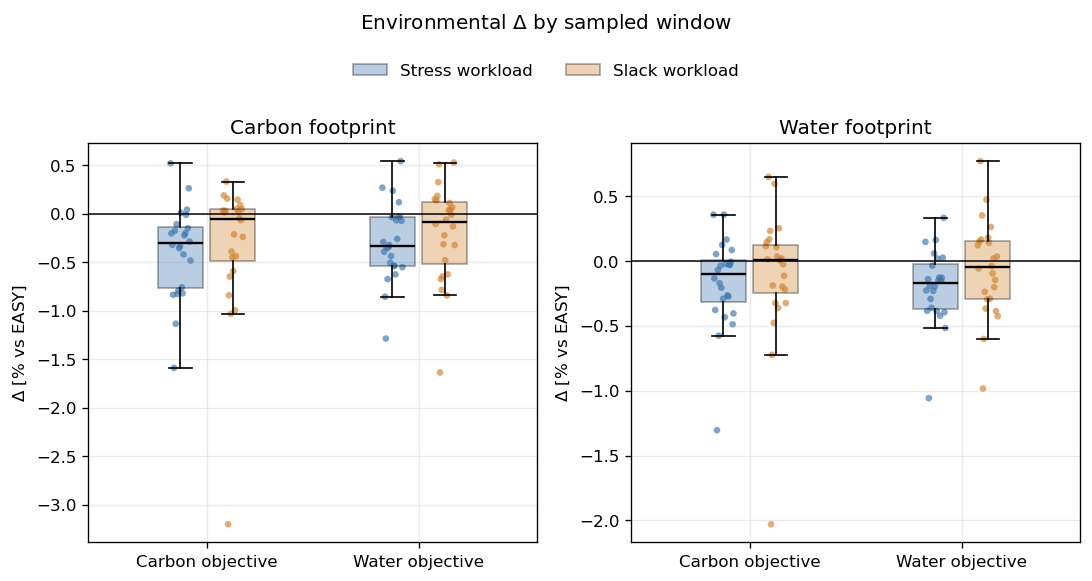

In [48]:
environmental_metrics = [
    "total_carbon_footprint_delta_pct",
    "total_water_footprint_delta_pct",
]
environmental_titles = ["Carbon footprint", "Water footprint"]
environmental_ylabels = [r"$\Delta$ [% vs EASY]"] * len(environmental_metrics)

plot_delta_boxes(
    easy_comparisons,
    environmental_metrics,
    environmental_titles,
    environmental_ylabels,
    r"Environmental $\Delta$ by sampled window",
);

This is the basic question: does greenfilling actually move the footprint it targets? Because the comparison is paired by window, a change in a high-carbon week and one in a low-carbon week each count within their own window. The spread is small for both workloads. If anything, the slack workload moves the footprint even less than stress (median saving near zero), so the extra scheduling room does not translate into a larger environmental gain here.

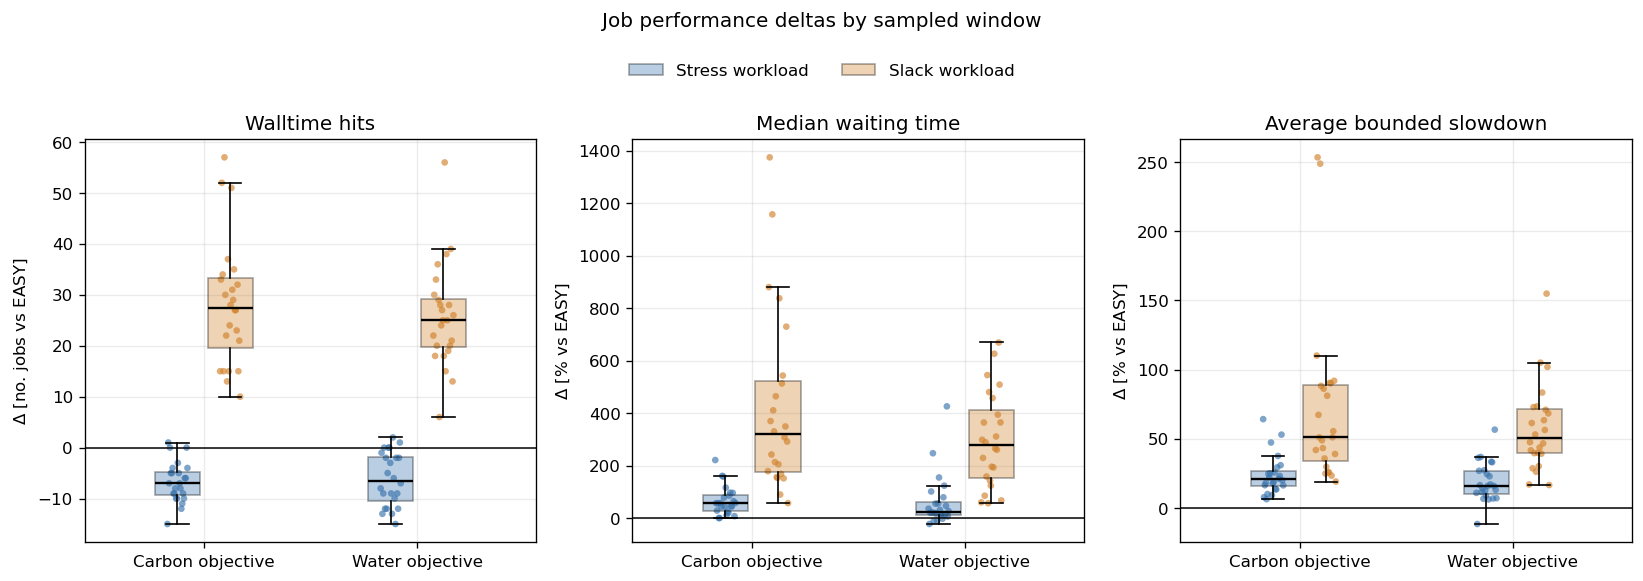

In [49]:
performance_metrics = [
    "replay_walltime_reached_delta",
    "replay_median_waiting_time_delta_pct",
    "replay_mean_bounded_slowdown_delta_pct",
]
performance_titles = [
    "Walltime hits",
    "Median waiting time",
    "Average bounded slowdown",
]
performance_ylabels = [r"$\Delta$ [no. jobs vs EASY]"] + [r"$\Delta$ [% vs EASY]"] * 2

plot_delta_boxes(
    easy_comparisons,
    performance_metrics,
    performance_titles,
    performance_ylabels,
    "Job performance deltas by sampled window",
);

Here the point is what that footprint change costs on the replay jobs. An environmental gain matters less if it comes with more killed jobs or a jump in slowdown, so it is worth checking how the performance cost compares to the (small) footprint movement.

## Environmental saving versus performance penalty

The boxes above show each axis on its own. The next two scatters try to show the trade-off directly: one point per window, environmental saving on x, replay slowdown penalty on y. Rows are the two workloads and columns are zones. Roughly, lower-right is the nice region (less footprint, no extra slowdown), upper-right is a real trade-off, and left of zero means the footprint got worse in that window.

In [50]:
from matplotlib.lines import Line2D


season_order = ["winter", "spring", "summer", "autumn"]
season_colors = {
    "winter": "#4c78a8",
    "spring": "#54a24b",
    "summer": "#f2a541",
    "autumn": "#b279a2",
}
objective_markers = {
    "greenfilling_carbon": "o",
    "greenfilling_water": "^",
}


def plot_tradeoff_scatter(data, environmental_delta_column, x_label, title):
    plot_data = data.copy()
    plot_data["environmental_saving_pct"] = -plot_data[environmental_delta_column]
    plot_data["bounded_slowdown_penalty_pct"] = plot_data[
        "replay_mean_bounded_slowdown_delta_pct"
    ]

    zones = sorted(plot_data["zone"].unique())
    fig, axes = plt.subplots(
        len(workload_order),
        len(zones),
        figsize=(4.4 * len(zones), 4.0 * len(workload_order)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    x_values = plot_data["environmental_saving_pct"]
    y_values = plot_data["bounded_slowdown_penalty_pct"]
    x_padding = max((x_values.max() - x_values.min()) * 0.12, 0.25)
    y_padding = max((y_values.max() - y_values.min()) * 0.12, 1.0)

    for row, workload in enumerate(workload_order):
        workload_data = plot_data[plot_data["workload_label"].eq(workload)]
        for ax, zone in zip(axes[row], zones):
            zone_data = workload_data[workload_data["zone"].eq(zone)]
            for variant in variant_order:
                variant_data = zone_data[zone_data["greenfilling_variant"].eq(variant)]
                for season in season_order:
                    points = variant_data[variant_data["season"].eq(season)]
                    ax.scatter(
                        points["environmental_saving_pct"],
                        points["bounded_slowdown_penalty_pct"],
                        marker=objective_markers[variant],
                        s=58,
                        color=season_colors[season],
                        edgecolor="black",
                        linewidth=0.55,
                        alpha=0.85,
                    )

            ax.axvline(0, color="black", linewidth=0.9)
            ax.axhline(0, color="black", linewidth=0.9)
            ax.set_title(f"{workload_labels[workload]} - {zone}")
            ax.set_xlabel(x_label)
            ax.set_xlim(x_values.min() - x_padding, x_values.max() + x_padding)
            ax.set_ylim(min(0, y_values.min() - y_padding), y_values.max() + y_padding)
        axes[row][0].set_ylabel("Average bounded slowdown penalty [% vs EASY]")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    objective_handles = [
        Line2D(
            [0],
            [0],
            marker=objective_markers[variant],
            linestyle="",
            color="black",
            label=variant_labels[variant],
            markersize=7,
        )
        for variant in variant_order
    ]

    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06), frameon=False)
    fig.legend(handles=objective_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04), frameon=False)
    fig.suptitle(title, y=1.12)
    fig.tight_layout()
    return fig, axes

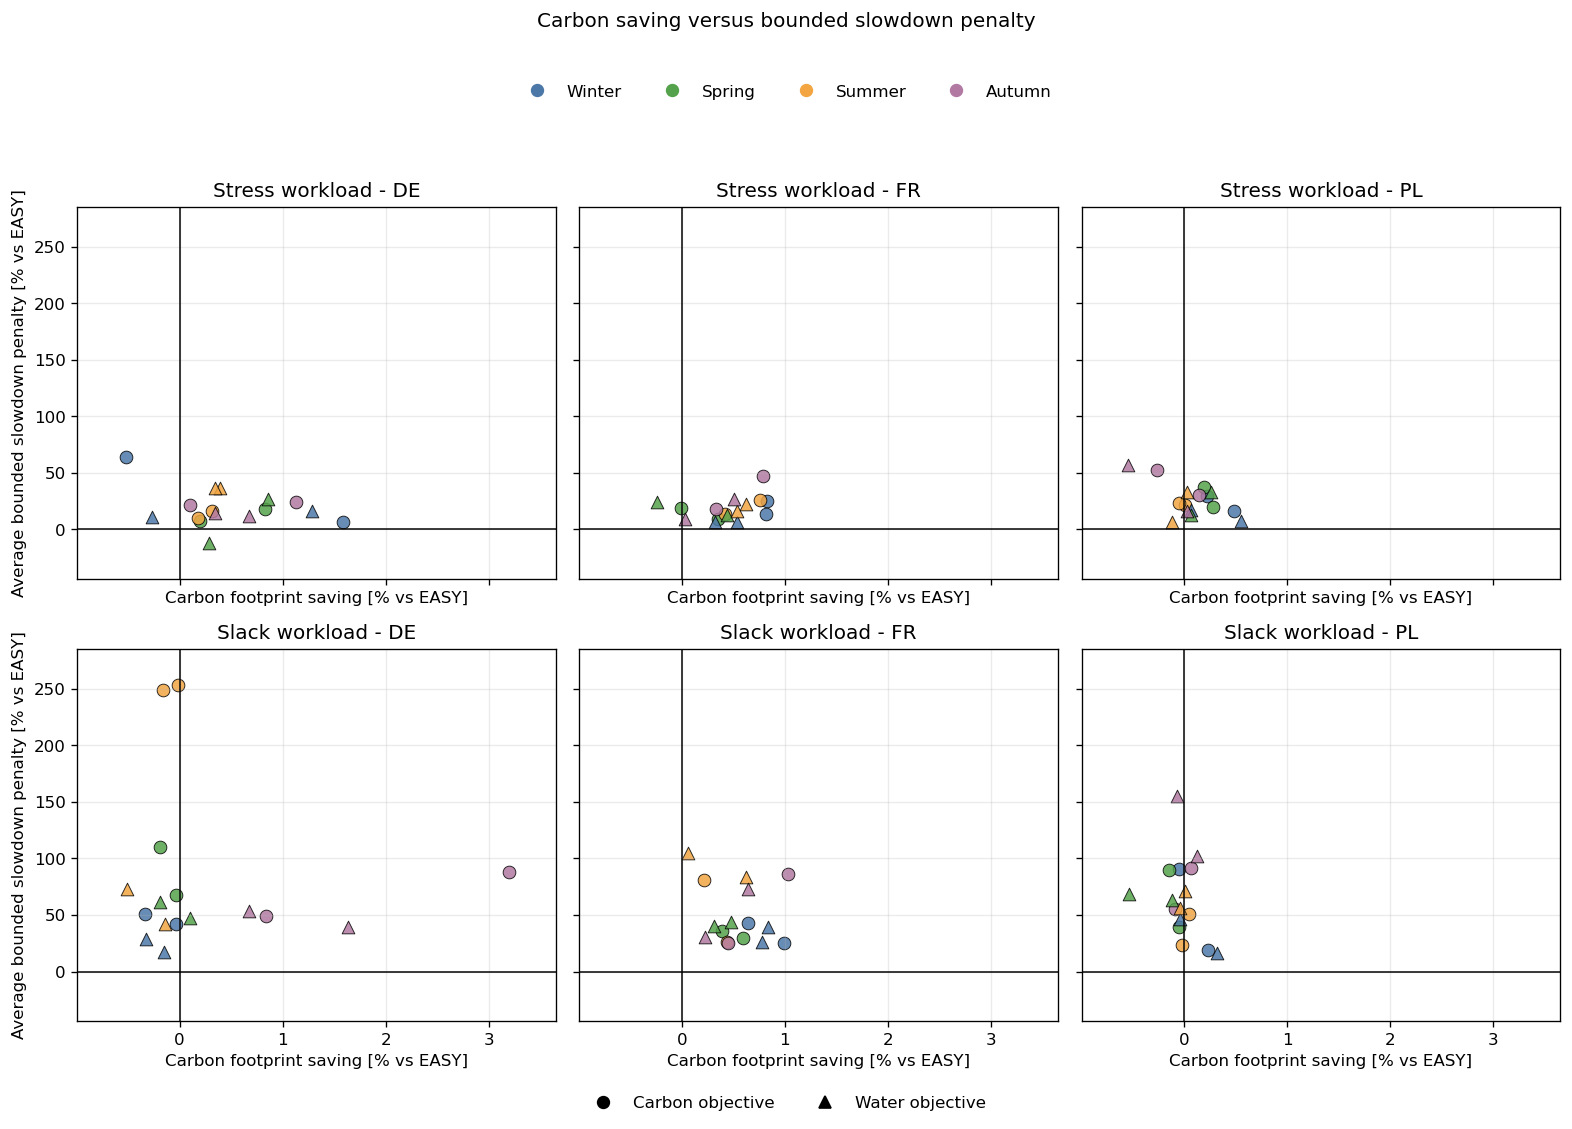

In [51]:
plot_tradeoff_scatter(
    easy_comparisons,
    "total_carbon_footprint_delta_pct",
    "Carbon footprint saving [% vs EASY]",
    "Carbon saving versus bounded slowdown penalty",
);

Carbon saving on the x-axis. I keep the water-objective points in too, since a scheduler tuned for one signal might still move the other.

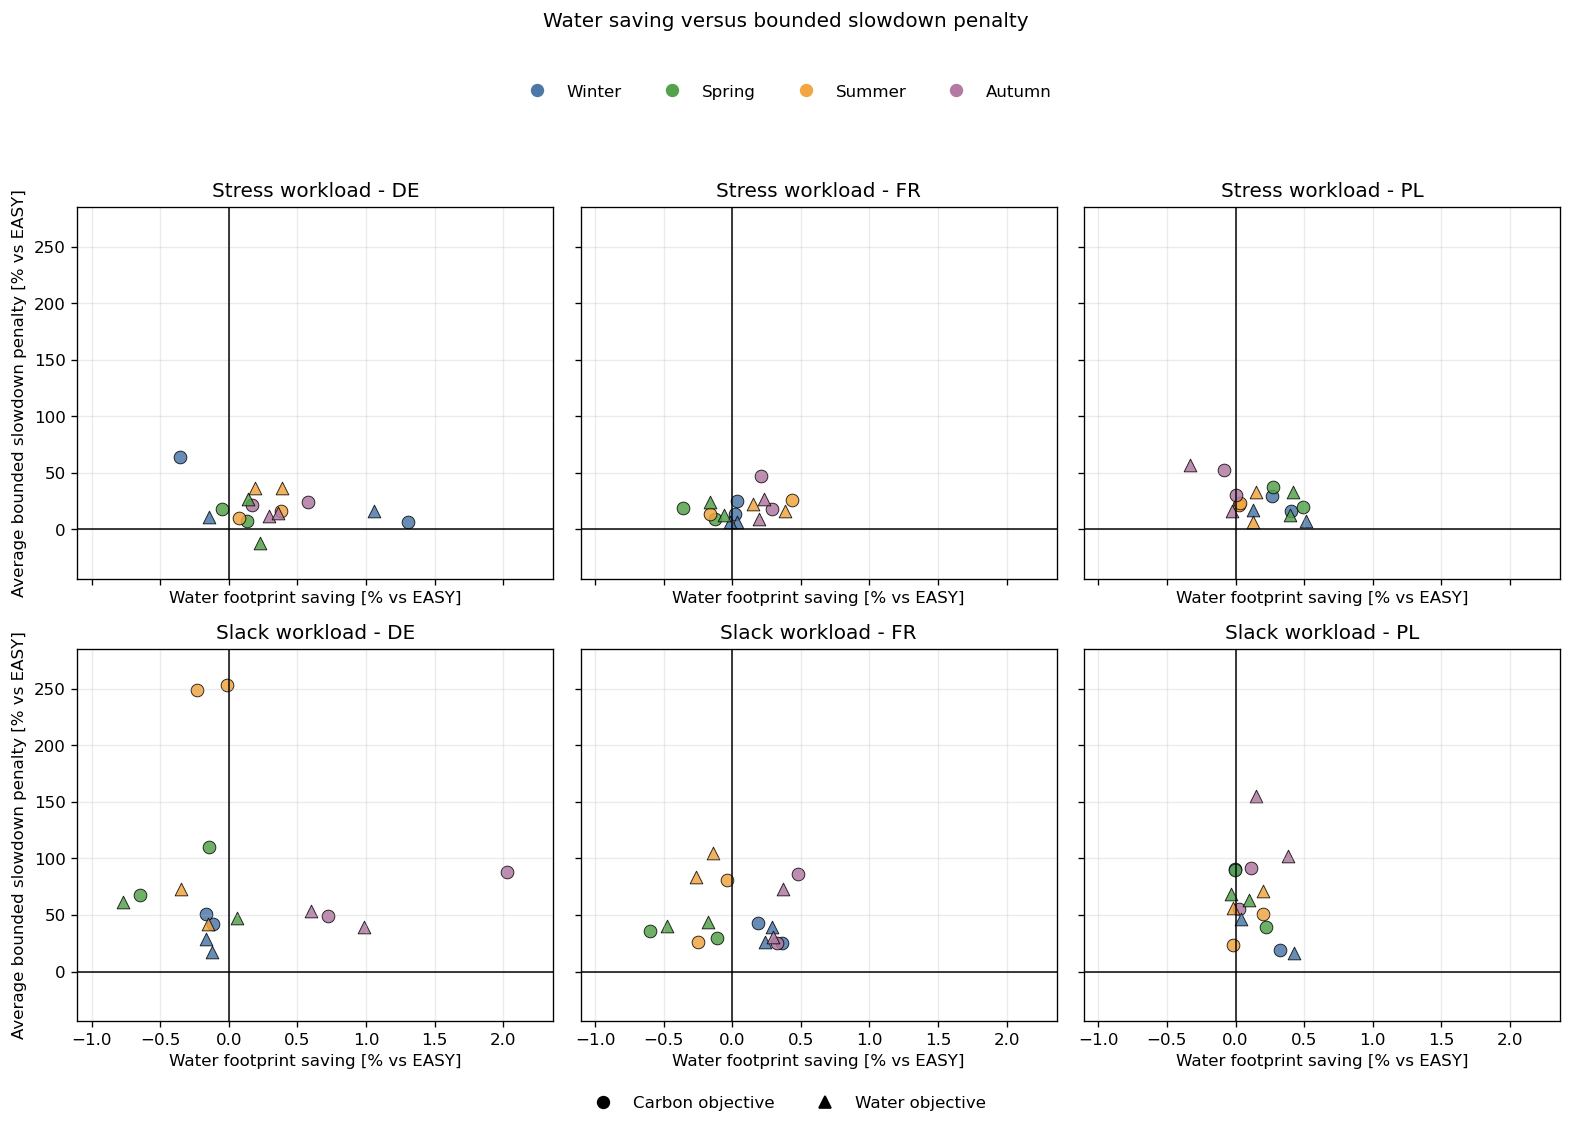

In [52]:
plot_tradeoff_scatter(
    easy_comparisons,
    "total_water_footprint_delta_pct",
    "Water footprint saving [% vs EASY]",
    "Water saving versus bounded slowdown penalty",
);

Same view for water. Putting it beside the carbon figure gives a rough sense of whether optimizing one signal helps or fights the other.

## Benefit-cost view: walltime hits

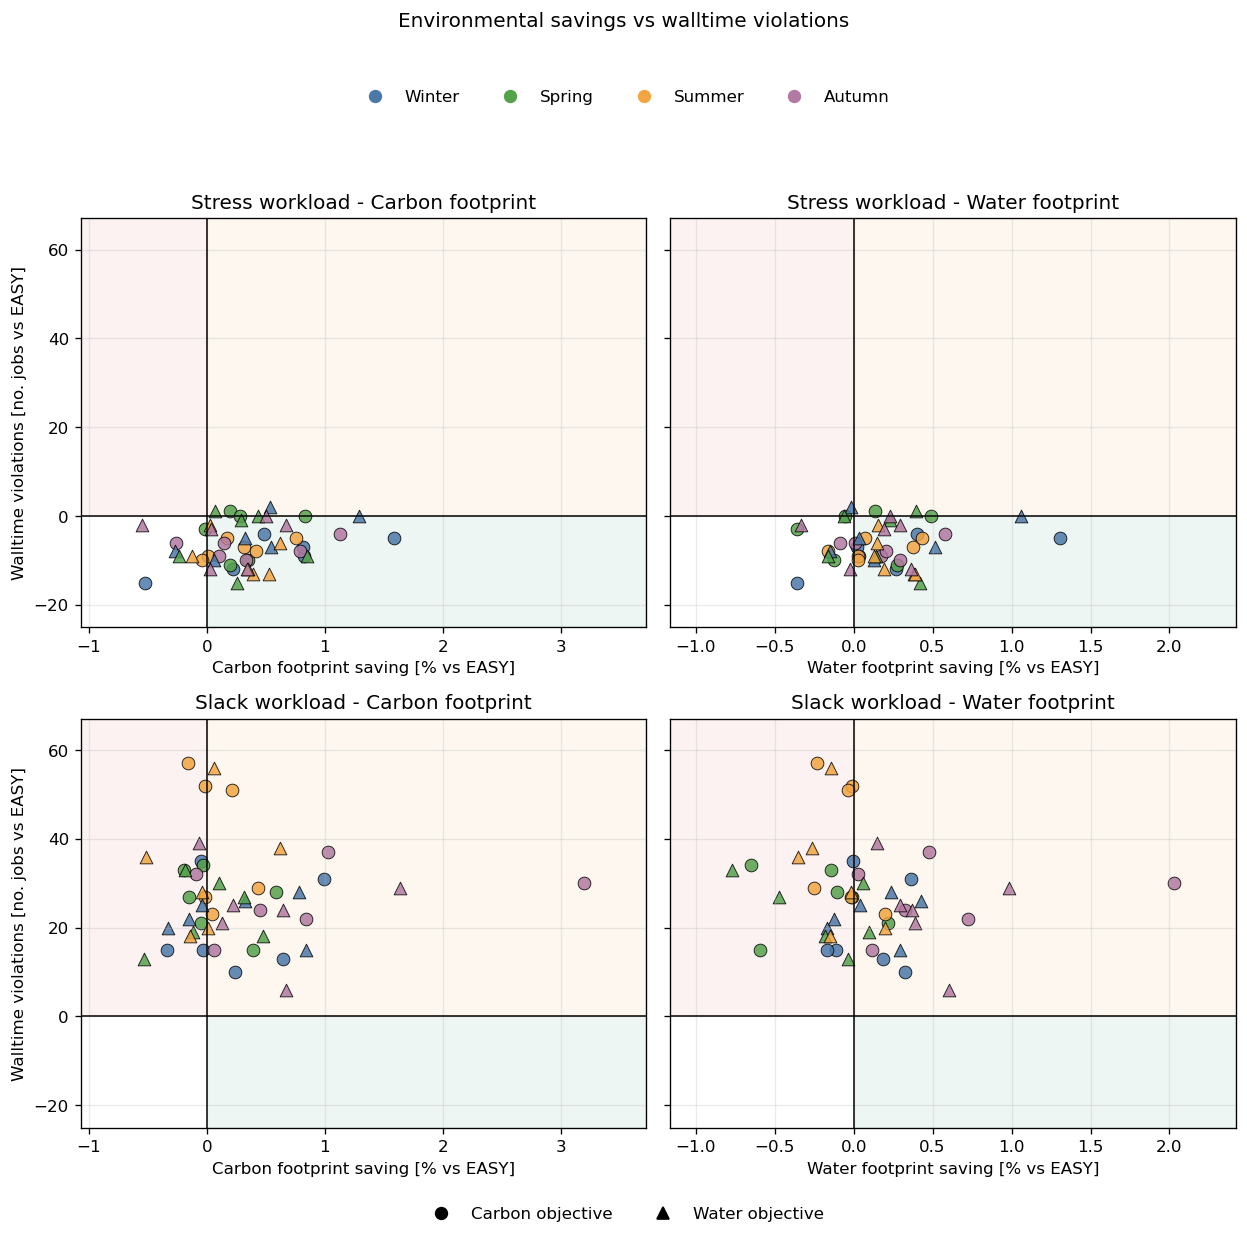

In [53]:
def plot_benefit_cost_quadrants(data):
    plot_specs = [
        ("total_carbon_footprint_delta_pct", "Carbon footprint saving [% vs EASY]", "Carbon footprint"),
        ("total_water_footprint_delta_pct", "Water footprint saving [% vs EASY]", "Water footprint"),
    ]

    fig, axes = plt.subplots(
        len(workload_order),
        len(plot_specs),
        figsize=(5.25 * len(plot_specs), 4.4 * len(workload_order)),
        sharey=True,
        squeeze=False,
    )
    plot_data = data.copy()

    # Shared y-range so the two workloads are read on the same scale.
    y_values = plot_data["replay_walltime_reached_delta"]
    y_padding = max((y_values.max() - y_values.min()) * 0.14, 1.0)
    y_lower = min(0, y_values.min() - y_padding)
    y_upper = max(0, y_values.max() + y_padding)

    # Shared per-column x-range across both workloads.
    column_bounds = []
    for delta_column, _, _ in plot_specs:
        saving = -plot_data[delta_column]
        x_padding = max((saving.max() - saving.min()) * 0.14, 0.25)
        column_bounds.append((saving.min() - x_padding, saving.max() + x_padding))

    for row, workload in enumerate(workload_order):
        workload_data = plot_data[plot_data["workload_label"].eq(workload)]
        for column, (ax, (delta_column, x_label, title)) in enumerate(zip(axes[row], plot_specs)):
            x_lower, x_upper = column_bounds[column]

            ax.fill_between([0, x_upper], y_lower, 0, color="#2f8f6b", alpha=0.08)
            ax.fill_between([0, x_upper], 0, y_upper, color="#f2a541", alpha=0.08)
            ax.fill_between([x_lower, 0], 0, y_upper, color="#d95f5f", alpha=0.08)

            for variant in variant_order:
                variant_data = workload_data[workload_data["greenfilling_variant"].eq(variant)]
                for season in season_order:
                    points = variant_data[variant_data["season"].eq(season)]
                    ax.scatter(
                        -points[delta_column],
                        points["replay_walltime_reached_delta"],
                        marker=objective_markers[variant],
                        s=58,
                        color=season_colors[season],
                        edgecolor="black",
                        linewidth=0.55,
                        alpha=0.85,
                    )

            ax.axvline(0, color="black", linewidth=0.9)
            ax.axhline(0, color="black", linewidth=0.9)
            ax.set_title(f"{workload_labels[workload]} - {title}")
            ax.set_xlabel(x_label)
            ax.set_xlim(x_lower, x_upper)
            ax.set_ylim(y_lower, y_upper)
        axes[row][0].set_ylabel("Walltime violations [no. jobs vs EASY]")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    objective_handles = [
        Line2D(
            [0],
            [0],
            marker=objective_markers[variant],
            linestyle="",
            color="black",
            label=variant_labels[variant],
            markersize=7,
        )
        for variant in variant_order
    ]

    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06), frameon=False)
    fig.legend(handles=objective_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04), frameon=False)
    fig.suptitle("Environmental savings vs walltime violations", y=1.12)
    fig.tight_layout()
    return fig, axes


plot_benefit_cost_quadrants(easy_comparisons);

This swaps the soft slowdown penalty for a harder one: the change in replay jobs that hit walltime. Lower-right is best (saving with no extra walltime hits), upper-right is the explicit trade-off, and upper-left would be the bad corner, worse footprint and more jobs killed.

## Does swing line up with the savings?

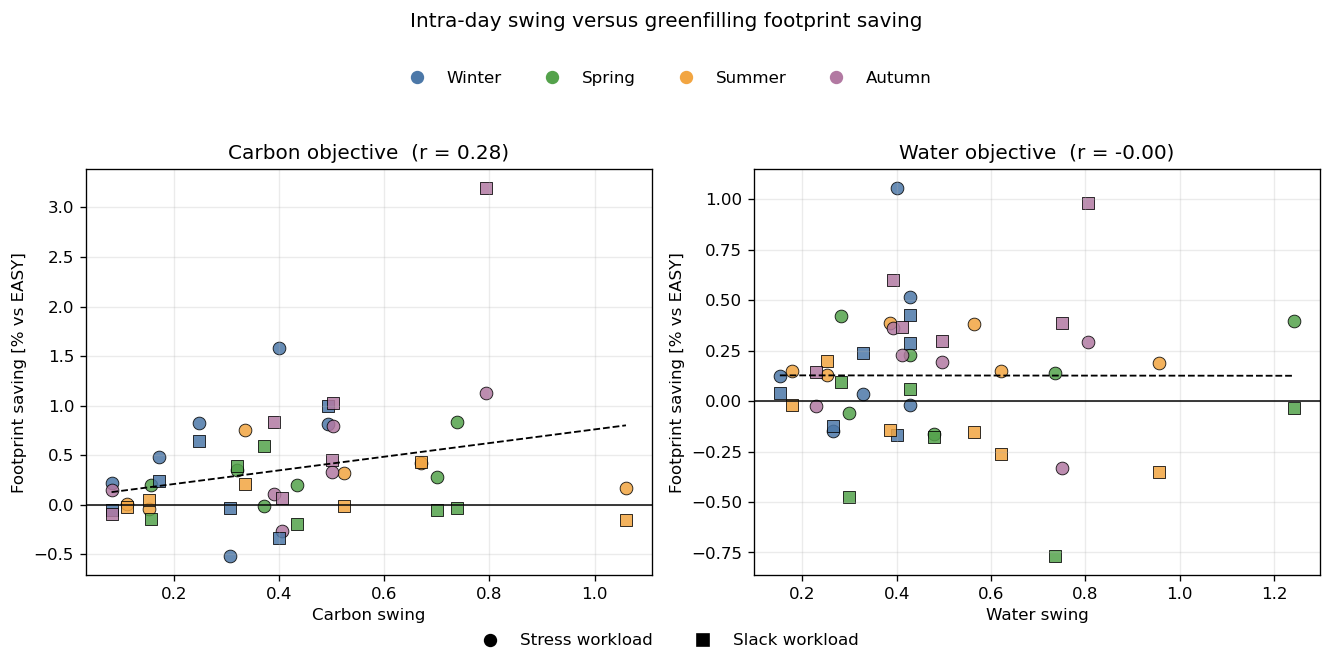

In [54]:
def plot_swing_relationship(data):
    specs = [
        ("greenfilling_carbon", "swing_carbon", "total_carbon_footprint_delta_pct", "Carbon objective", "Carbon swing"),
        ("greenfilling_water", "swing_water", "total_water_footprint_delta_pct", "Water objective", "Water swing"),
    ]

    fig, axes = plt.subplots(1, len(specs), figsize=(5.6 * len(specs), 4.6), squeeze=False)
    axes = axes[0]

    for ax, (variant, swing_column, delta_column, title, x_label) in zip(axes, specs):
        variant_data = data[data["greenfilling_variant"].eq(variant)]

        for workload in workload_order:
            subset = variant_data[variant_data["workload_label"].eq(workload)]
            for season in season_order:
                points = subset[subset["season"].eq(season)]
                ax.scatter(
                    points[swing_column],
                    -points[delta_column],
                    color=season_colors[season],
                    edgecolor="black",
                    linewidth=0.55,
                    s=58,
                    alpha=0.85,
                    marker=workload_markers[workload],
                )

        # Fit and correlation over all points, both workloads pooled.
        swing = variant_data[swing_column].to_numpy()
        saving = -variant_data[delta_column].to_numpy()  # positive = footprint reduction vs EASY
        if len(swing) > 1:
            slope, intercept = np.polyfit(swing, saving, 1)
            grid = np.linspace(swing.min(), swing.max(), 50)
            ax.plot(grid, slope * grid + intercept, color="black", linestyle="--", linewidth=1.1)
            r = np.corrcoef(swing, saving)[0, 1]
            ax.set_title(f"{title}  (r = {r:.2f})")
        else:
            ax.set_title(title)

        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Footprint saving [% vs EASY]")

    season_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=season_colors[season], label=season.title(), markersize=7)
        for season in season_order
    ]
    workload_handles = [
        Line2D([0], [0], marker=workload_markers[workload], linestyle="", color="black", label=workload_labels[workload], markersize=7)
        for workload in workload_order
    ]
    fig.legend(handles=season_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06), frameon=False)
    fig.legend(handles=workload_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04), frameon=False)
    fig.suptitle("Intra-day swing versus greenfilling footprint saving", y=1.14)
    fig.tight_layout()
    return fig, axes


plot_swing_relationship(easy_comparisons);

`swing` is the mean daily peak-to-trough range of a signal over the window mean, so it is a rough proxy for how much daily variation the signal has. The loose idea is that more variation might give the scheduler more to work with, so savings could grow with swing. Each panel pairs a signal's swing with greenfilling's saving for the matching objective; both workloads share the panel (marker shape encodes workload), and the dashed least-squares fit and `r` pool all points across both workloads. With 48 windows per objective and sub-percent effects this is suggestive at best, and I would not lean on the exact value.

## Takeaway

On the stress workload, greenfilling moves the footprint very little (median around -0.3% vs EASY, and the wrong way in some windows), while the replay jobs see somewhat longer waiting and higher slowdown (median bounded slowdown up roughly 16-21%). Fewer replay jobs hit walltime than under EASY. The carbon and water objectives look about the same.

The slack workload does not behave the way I expected. I added it thinking more scheduling room would let greenfilling find a larger environmental gain. Instead the footprint barely moves at all (median saving near zero, and positive in only about half the windows), while the performance cost is larger than on stress: replay success rate drops a few percent, more replay jobs hit walltime (median around +25 jobs vs EASY), and median waiting time and bounded slowdown rise sharply. So the extra room buys a worse trade-off, not a better one.

The headline across both workloads is the same: greenfilling as set up here pays a real performance cost for an environmental gain that is at best tiny. The slack result also undercuts the earlier guess that a less busy schedule would help, so it is worth digging into why the slack workload reacts the way it does before pushing this further.